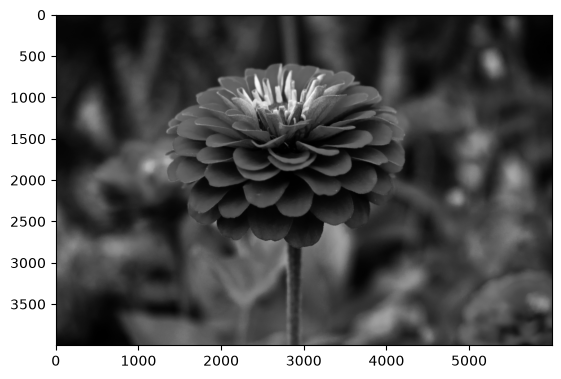

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")
plt.show()

# 1.1 Зашумить изображение при помощи шума Гаусса

In [2]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ..., 150,  56,   0],
       [ 86,   0, 238, ...,   0,   0,  36],
       [ 39, 106,   0, ...,   0, 194,   0],
       ...,
       [  0,   0,  36, ...,   0,  35, 139],
       [  0,   0,   0, ...,   0, 106,   0],
       [102,   0,   0, ...,   0,  67,   0]],
      shape=(4000, 6000), dtype=uint8)

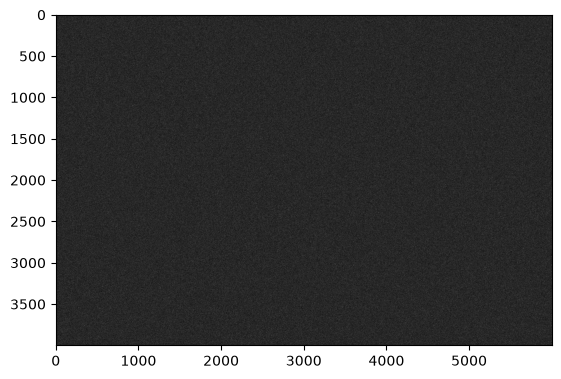

In [3]:
plt.imshow(noise_gauss, cmap="gray")

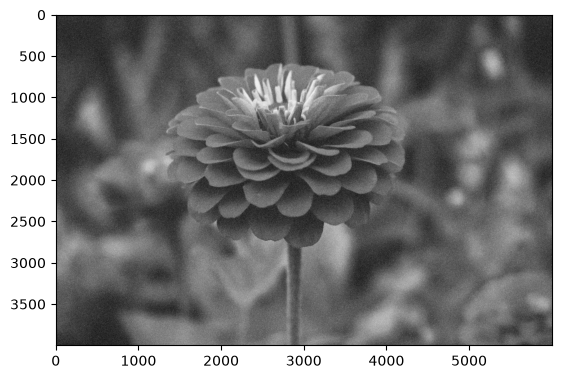

In [4]:
image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap="gray")

# 1.2 Зашумить изображение при помощи постоянного шума

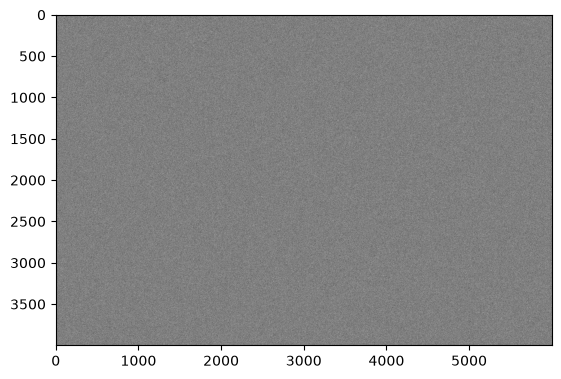

In [8]:
a = 50
noise_uniform = np.random.randint(-a, a + 1,
                                  size=image_gray.shape,
                                  dtype=np.int16)

plt.imshow(noise_uniform, cmap="gray")

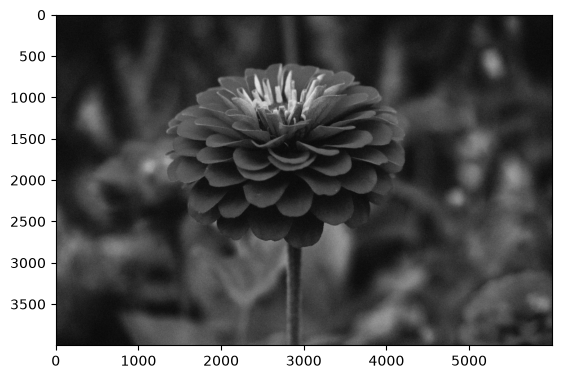

In [6]:
image_noise_uniform = np.clip(
    image_gray.astype(np.int16) + noise_uniform, 0, 255
).astype(np.uint8)

plt.imshow(image_noise_uniform, cmap="gray")

# 2.1 Оценка исходного зашумления

In [9]:
from skimage.metrics import structural_similarity, mean_squared_error

mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim_gauss)

mse_uniform = mean_squared_error(image_gray, image_noise_uniform)
ssim_uniform, _ = structural_similarity(image_gray, image_noise_uniform, full=True)
print(mse_uniform, ssim_uniform)

4498.495616958333 0.025890101157439005
760.2460549166667 0.10079081662115216


# 2.2 Медианный фильтр с разными параметрами

In [10]:
# Гауссов шум
image_gauss_median_3 = cv2.medianBlur(image_noise_gauss, 3)
mse = mean_squared_error(image_gray, image_gauss_median_3)
ssim, _ = structural_similarity(image_gray, image_gauss_median_3, full=True)
print("Гаусс + медиана 3:", mse, ssim)

image_gauss_median_5 = cv2.medianBlur(image_noise_gauss, 5)
mse = mean_squared_error(image_gray, image_gauss_median_5)
ssim, _ = structural_similarity(image_gray, image_gauss_median_5, full=True)
print("Гаусс + медиана 5:", mse, ssim)

# Постоянный шум
image_uniform_median_3 = cv2.medianBlur(image_noise_uniform, 3)
mse = mean_squared_error(image_gray, image_uniform_median_3)
ssim, _ = structural_similarity(image_gray, image_uniform_median_3, full=True)
print("Постоянный + медиана 3:", mse, ssim)

image_uniform_median_5 = cv2.medianBlur(image_noise_uniform, 5)
mse = mean_squared_error(image_gray, image_uniform_median_5)
ssim, _ = structural_similarity(image_gray, image_uniform_median_5, full=True)
print("Постоянный + медиана 5:", mse, ssim)

Гаусс + медиана 3: 844.0684315833333 0.1536194148874991
Гаусс + медиана 5: 333.2517864166667 0.36576247704714865
Постоянный + медиана 3: 225.16929566666667 0.26394406379424995
Постоянный + медиана 5: 102.78048070833333 0.4568723217385602


# 2.3 Фильтр Гаусса с разными параметрами

In [12]:
# Гауссов шум
image_gauss_gauss_3 = cv2.GaussianBlur(image_noise_gauss, (3, 3), 0)
mse = mean_squared_error(image_gray, image_gauss_gauss_3)
ssim, _ = structural_similarity(image_gray, image_gauss_gauss_3, full=True)
print("Гаусс + Гаусс 3:", mse, ssim)

image_gauss_gauss_5 = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
mse = mean_squared_error(image_gray, image_gauss_gauss_5)
ssim, _ = structural_similarity(image_gray, image_gauss_gauss_5, full=True)
print("Гаусс + Гаусс 5:", mse, ssim)

# Постоянный шум
image_uniform_gauss_3 = cv2.GaussianBlur(image_noise_uniform, (3, 3), 0)
mse = mean_squared_error(image_gray, image_uniform_gauss_3)
ssim, _ = structural_similarity(image_gray, image_uniform_gauss_3, full=True)
print("Постоянный + Гаусс 3:", mse, ssim)

image_uniform_gauss_5 = cv2.GaussianBlur(image_noise_uniform, (5, 5), 0)
mse = mean_squared_error(image_gray, image_uniform_gauss_5)
ssim, _ = structural_similarity(image_gray, image_uniform_gauss_5, full=True)
print("Постоянный + Гаусс 5:", mse, ssim)

Гаусс + Гаусс 3: 1926.513640625 0.14123068983097767
Гаусс + Гаусс 5: 1729.2054128333334 0.2304045520784348
Постоянный + Гаусс 3: 121.83812929166666 0.41443701229336194
Постоянный + Гаусс 5: 75.14231908333333 0.5512843905979946


# 2.4 Билатериальный фильтр с разными параметрами

In [11]:
# Гауссов шум
image_gauss_bilat_1 = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
mse = mean_squared_error(image_gray, image_gauss_bilat_1)
ssim, _ = structural_similarity(image_gray, image_gauss_bilat_1, full=True)
print("Гаусс + билатеральный (9,75,75):", mse, ssim)

image_gauss_bilat_2 = cv2.bilateralFilter(image_noise_gauss, 5, 50, 50)
mse = mean_squared_error(image_gray, image_gauss_bilat_2)
ssim, _ = structural_similarity(image_gray, image_gauss_bilat_2, full=True)
print("Гаусс + билатеральный (5,50,50):", mse, ssim)

# Постоянный шум
image_uniform_bilat_1 = cv2.bilateralFilter(image_noise_uniform, 9, 75, 75)
mse = mean_squared_error(image_gray, image_uniform_bilat_1)
ssim, _ = structural_similarity(image_gray, image_uniform_bilat_1, full=True)
print("Постоянный + билатеральный (9,75,75):", mse, ssim)

image_uniform_bilat_2 = cv2.bilateralFilter(image_noise_uniform, 5, 50, 50)
mse = mean_squared_error(image_gray, image_uniform_bilat_2)
ssim, _ = structural_similarity(image_gray, image_uniform_bilat_2, full=True)
print("Постоянный + билатеральный (5,50,50):", mse, ssim)

Гаусс + билатеральный (9,75,75): 1786.3903612083334 0.1045069515651392
Гаусс + билатеральный (5,50,50): 3048.22732575 0.042669132710610895
Постоянный + билатеральный (9,75,75): 49.90049391666667 0.6641589000045597
Постоянный + билатеральный (5,50,50): 137.45217295833334 0.3854989378575123


# 2.5 Фильтр нелокальных средних с разными параметрами

In [13]:
# Гауссов шум
image_gauss_nlm_10 = cv2.fastNlMeansDenoising(image_noise_gauss, h=10)
mse = mean_squared_error(image_gray, image_gauss_nlm_10)
ssim, _ = structural_similarity(image_gray, image_gauss_nlm_10, full=True)
print("Гаусс + NLM h=10:", mse, ssim)

image_gauss_nlm_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)
mse = mean_squared_error(image_gray, image_gauss_nlm_20)
ssim, _ = structural_similarity(image_gray, image_gauss_nlm_20, full=True)
print("Гаусс + NLM h=20:", mse, ssim)

# Постоянный шум
image_uniform_nlm_10 = cv2.fastNlMeansDenoising(image_noise_uniform, h=10)
mse = mean_squared_error(image_gray, image_uniform_nlm_10)
ssim, _ = structural_similarity(image_gray, image_uniform_nlm_10, full=True)
print("Постоянный + NLM h=10:", mse, ssim)

image_uniform_nlm_20 = cv2.fastNlMeansDenoising(image_noise_uniform, h=20)
mse = mean_squared_error(image_gray, image_uniform_nlm_20)
ssim, _ = structural_similarity(image_gray, image_uniform_nlm_20, full=True)
print("Постоянный + NLM h=20:", mse, ssim)

Гаусс + NLM h=10: 4498.358609625 0.02608514366593419
Гаусс + NLM h=20: 4486.269640875 0.028931002176420983
Постоянный + NLM h=10: 746.4352159583333 0.10691718359268976
Постоянный + NLM h=20: 48.09541320833333 0.6608776414762707


# 3. Лучшие результаты:

Для гауссова шума лучший результат показал медианный фильтр 5×5 (MSE = 333.25, SSIM = 0.3658), так как он эффективно подавляет импульсные выбросы. 



Для постоянного (равномерного) шума наилучшими оказались NLM h=20 (MSE = 48.10, SSIM = 0.6609) и билатеральный фильтр (9,75,75) (MSE = 49.90, SSIM = 0.6642) — они сохраняют границы и хорошо усредняют плавные области, тогда как медиана и гауссов фильтр работают заметно слабее.